# 01 · Quickstart — APS HDF5 to reconstruction

**Audience:** beamline users who already have an HDF5 file in the APS
*data exchange* layout (`/exchange/data`, `/exchange/dark`,
`/exchange/bright` + scan parameters).

**Goal:** in ~10 steps, take that file all the way to an inspectable
reconstruction. We use a tiny synthetic file so this runs in seconds —
swap in your real HDF5 path at the top of the notebook to apply the
same workflow to your data.

**Prerequisites:** `MIDAS_TOMO` built (`cd ~/opt/MIDAS/build && cmake
--build . --target MIDAS_TOMO`) and the `midas_env` conda env.


In [1]:
# --- Setup ---------------------------------------------------------
%matplotlib inline
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Make the MIDAS TOMO Python API importable
MIDAS_TOMO = os.path.expanduser('~/opt/MIDAS/TOMO')
if MIDAS_TOMO not in sys.path:
    sys.path.insert(0, MIDAS_TOMO)
NB_DIR = os.path.join(MIDAS_TOMO, 'notebooks')
if NB_DIR not in sys.path:
    sys.path.insert(0, NB_DIR)

import _phantom as phantom

# Working directory for this notebook's outputs
WORK = os.path.expanduser('~/tomo_notebooks/01_hdf5')
os.makedirs(WORK, exist_ok=True)
print('Working dir:', WORK)


Working dir: /Users/hsharma/tomo_notebooks/01_hdf5


## 1 · Make (or point at) a synthetic HDF5 file

The phantom is a tapered support pillar topped with a sample sphere — the
classic in-situ tomo geometry. We project 180 angles from 0° to 180°
over a small 64×64 detector and inject a few dead detector columns so
you can see ring artefacts in the baseline reconstruction.

**To run on your own data**, set `H5_PATH` to your file and skip cell 1.2.


In [2]:
H5_PATH = os.path.join(WORK, 'phantom.h5')

vol = phantom.make_phantom(64, 64, 64)
angles = np.arange(0, 180, 1.0, dtype=np.float32)
acq = phantom.make_acquisition(vol, angles, add_rings=True)
phantom.write_synthetic_hdf5(H5_PATH, acq, shift=0.0,
                             crop_xl=2, crop_xr=2, crop_zl=2, crop_zr=2)
print(f'Wrote {H5_PATH}  ({os.path.getsize(H5_PATH) / 1e6:.1f} MB)')
print('Injected ring-source columns:', sorted(acq.ring_columns.tolist()))


Wrote /Users/hsharma/tomo_notebooks/01_hdf5/phantom.h5  (1.7 MB)
Injected ring-source columns: [12, 28, 34]


## 2 · Peek at the HDF5 structure

Before reconstructing anything, always check the file has what you
expect. The `process_hdf.py` driver requires the four datasets and
five parameters listed below.


In [3]:
import h5py
with h5py.File(H5_PATH, 'r') as f:
    def show(name, obj):
        if hasattr(obj, 'shape'):
            print(f'  {name:60s}  shape={obj.shape}  dtype={obj.dtype}')
    f.visititems(show)


  analysis/process/analysis_parameters/CropXL                   shape=(1,)  dtype=int64
  analysis/process/analysis_parameters/CropXR                   shape=(1,)  dtype=int64
  analysis/process/analysis_parameters/CropZL                   shape=(1,)  dtype=int64
  analysis/process/analysis_parameters/CropZR                   shape=(1,)  dtype=int64
  analysis/process/analysis_parameters/shift                    shape=(1,)  dtype=float64
  exchange/bright                                               shape=(20, 64, 64)  dtype=uint16
  exchange/dark                                                 shape=(1, 64, 64)  dtype=uint16
  exchange/data                                                 shape=(180, 64, 64)  dtype=uint16
  measurement/process/scan_parameters/start                     shape=(1,)  dtype=float64
  measurement/process/scan_parameters/step                      shape=(1,)  dtype=float64


## 3 · Visualize a raw projection, the dark, and the bright

Sanity-check that none of the frames is empty / saturated / clipped.


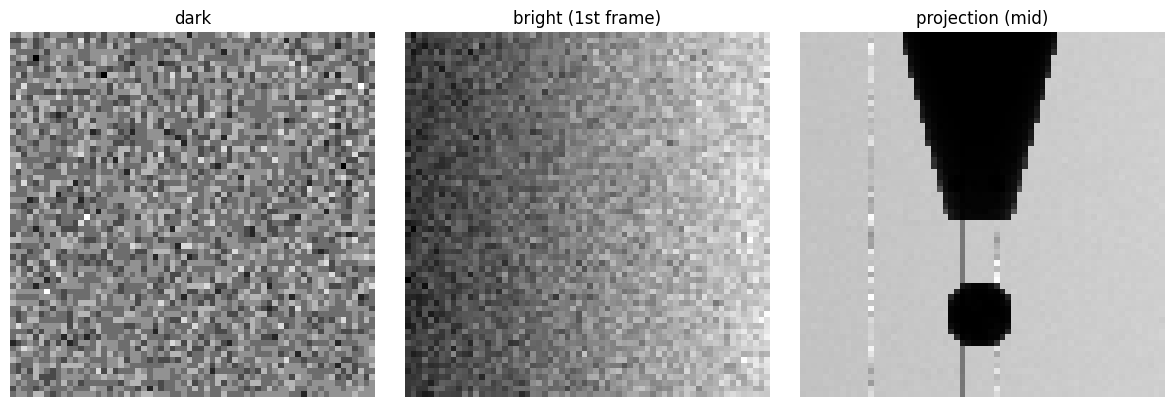

In [4]:
with h5py.File(H5_PATH, 'r') as f:
    dark = f['exchange/dark'][0].astype(np.float32)
    bright0 = f['exchange/bright'][0].astype(np.float32)
    proj_mid = f['exchange/data'][len(f['exchange/data']) // 2].astype(np.float32)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for a, im, t in zip(ax, [dark, bright0, proj_mid],
                    ['dark', 'bright (1st frame)', 'projection (mid)']):
    a.imshow(im, cmap='gray'); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()


## 4 · Visualize a normalized sinogram

The sinogram is what gridrec actually reconstructs from. We normalize
one slice by `(data - dark) / (bright - dark)` and apply `-log` to get
the line integrals (absorption contrast).

Vertical streaks across the sinogram are the smoking gun for **ring
artefacts** — they come from miscalibrated, dead, or fluctuating
detector columns. Notebook 03 shows how to fix them.


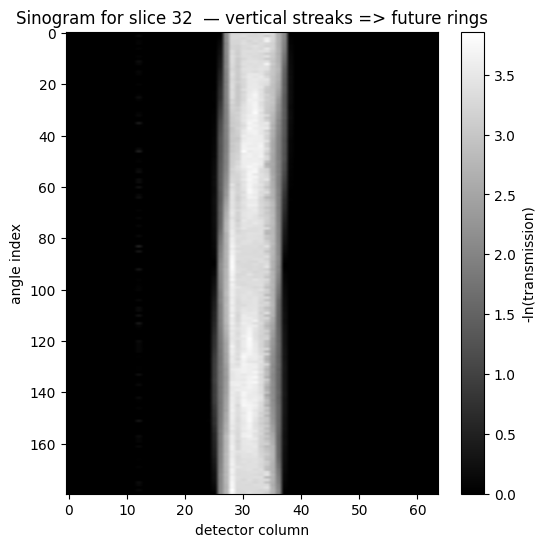

In [5]:
with h5py.File(H5_PATH, 'r') as f:
    sl = f['exchange/data'].shape[1] // 2   # middle slice
    data_sl = f['exchange/data'][:, sl, :].astype(np.float32)
    dark_sl = f['exchange/dark'][0, sl, :].astype(np.float32)
    bright_sl = f['exchange/bright'][:, sl, :].astype(np.float32).mean(0)

eps = 1e-3
norm = np.clip((data_sl - dark_sl) / (bright_sl - dark_sl + eps), eps, 1.0)
sino = -np.log(norm)

plt.figure(figsize=(6, 6))
plt.imshow(sino, aspect='auto', cmap='gray')
plt.xlabel('detector column')
plt.ylabel('angle index')
plt.title(f'Sinogram for slice {sl}  — vertical streaks => future rings')
plt.colorbar(label='-ln(transmission)')
plt.show()


## 5 · Run the reconstruction (CLI path)

`process_hdf.py` is the one-command wrapper. With no extra flags it
uses the single shift value stored in the HDF5 file. We'll show the
cleanup-tuning flag in §6.


In [6]:
import subprocess
cmd = ['python', os.path.join(MIDAS_TOMO, 'process_hdf.py'),
       '-dataFN', H5_PATH, '-nCPUs', '4']
print('Running:', ' '.join(cmd))
result = subprocess.run(cmd, cwd=WORK, capture_output=True, text=True)
print(result.stdout[-1200:])
if result.returncode != 0:
    print('STDERR:', result.stderr[-800:])


Running: python /Users/hsharma/opt/MIDAS/TOMO/process_hdf.py -dataFN /Users/hsharma/tomo_notebooks/01_hdf5/phantom.h5 -nCPUs 4



STDERR: Traceback (most recent call last):
  File "/Users/hsharma/opt/MIDAS/TOMO/process_hdf.py", line 257, in <module>
    main()
  File "/Users/hsharma/opt/MIDAS/TOMO/process_hdf.py", line 168, in main
    nX, nY = dark.shape
    ^^^^^^
ValueError: too many values to unpack (expected 2)



## 6 · Or run via the Python API (gives you the cube directly)

Useful when you want the reconstruction in memory, e.g. for batch
analysis or for chaining into other MIDAS modules.


In [7]:
from midas_tomo_python import run_tomo

# The HDF5 has separate before/after white sets; for run_tomo we pass
# the average of each side as the 2-frame whites array.
with h5py.File(H5_PATH, 'r') as f:
    dark = f['exchange/dark'][0].astype(np.float32)
    nw = f['exchange/bright'].shape[0]
    bright = f['exchange/bright'][:].astype(np.float32)
    whites = np.stack([bright[:nw//2].mean(0), bright[nw//2:].mean(0)])
    data = f['exchange/data'][:].astype(np.uint16)
    shift = float(f['analysis/process/analysis_parameters/shift'][0])
    nFrames = data.shape[0]
    st = float(f['measurement/process/scan_parameters/start'][0])
    sp = float(f['measurement/process/scan_parameters/step'][0])
angles_h5 = np.linspace(st, st + sp * (nFrames - 1), num=nFrames)

recon = run_tomo(data, dark, whites, WORK, angles_h5,
                 shifts=shift, numCPUs=4, doCleanup=1)
print('recon shape:', recon.shape)  # (n_shifts, n_slices, xDim, xDim)


Time elapsed in preprocessing: 0.003s.
Version: MIDAS v11.0 (8a155821)
Total number of thetas: 180
We are doing all slices. Total number of slices: 64

          MIDAS TOMO - Configuration Summary
  Data Input:
    Data File       : /Users/hsharma/tomo_notebooks/01_hdf5/input.bin
    Input Type      : Raw Projections
    Recon Output    : /Users/hsharma/tomo_notebooks/01_hdf5/output
  Detector:
    Dimensions      : 64 x 64 (X x Y)
  Angles:
    Theta Count     : 180
    Range           : 0.00 to 179.00
  Reconstruction:
    Filter          : 2
    Shift Range     : 0.00 to 0.00 (step 1.00, n=1)
    Slices          : 64
    Auto Centering  : Yes
    Log Projection  : Yes
    Extra Padding   : 0
    Save Separate   : No
  Corrections:
    Ring Removal    : No
    Stripe Removal  : No

Sinograms are a power of 2!
Reading wisdom file fftwf_wisdom_2d_128.txt.
Memory needed per process: 1573050, Total available RAM: 68719476736, MaxNProcs: 43685.
We can run up to 43683 processes.
We will us

## 7 · Inspect the reconstruction

Three diagnostic views every tomo recon should pass:

1. **A mid-stack axial slice** (XY) — should show recognisable sample
   geometry.
2. **Orthogonal sagittal/coronal cuts** (XZ, YZ) — confirms the
   reconstruction is 3-D coherent, not just 2-D-pretty.
3. **Histograms** — sanity-check the intensity scale; large outliers
   point to normalisation issues.


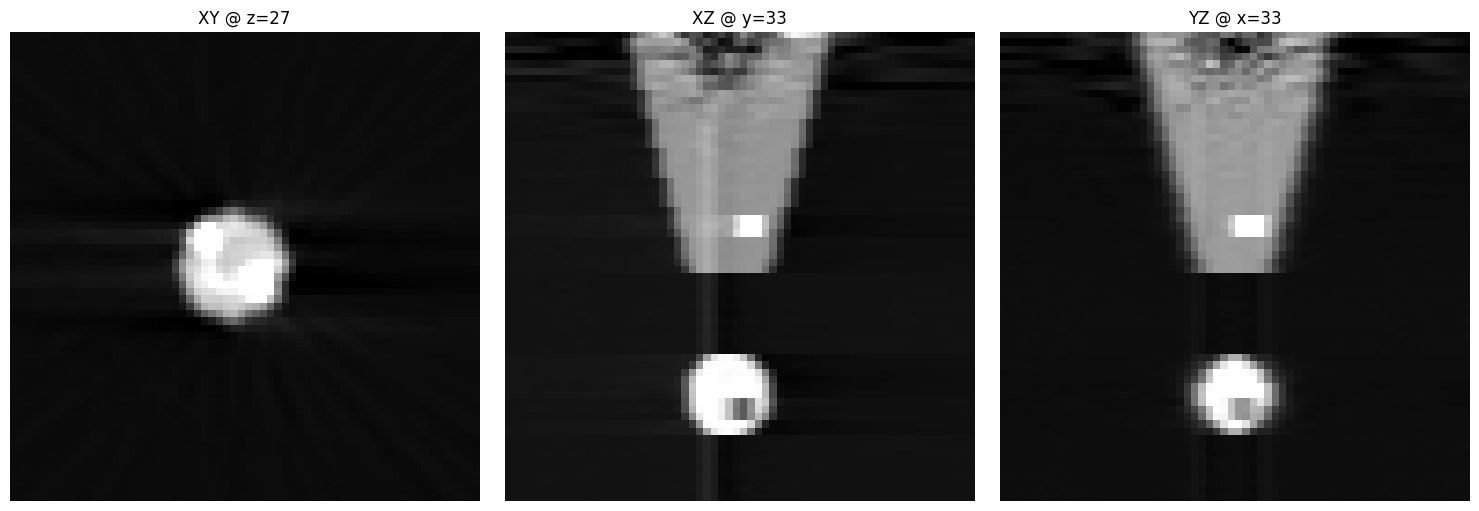

In [8]:
cube = recon[0]   # single shift → drop that axis
nz = cube.shape[0]
zb, yb, xb = np.unravel_index(np.argmax(cube), cube.shape)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
cuts = [cube[zb], cube[:, yb, :], cube[:, :, xb]]
titles = [f'XY @ z={zb}', f'XZ @ y={yb}', f'YZ @ x={xb}']
for a, im, t in zip(ax, cuts, titles):
    vmin, vmax = np.percentile(im, 1), np.percentile(im, 99)
    a.imshow(im, cmap='gray', vmin=vmin, vmax=vmax, aspect='equal')
    a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()


## 8 · Save the reconstruction as a multi-page TIFF

A TIFF stack is the most portable artefact — opens in ImageJ/Fiji,
napari, and most image viewers without any special MIDAS support.


In [9]:
import tifffile
out_tif = os.path.join(WORK, 'recon_quickstart.tif')
tifffile.imwrite(out_tif, cube.astype(np.float32),
                 imagej=True, metadata={'axes': 'ZYX'})
print(f'Wrote {out_tif}  ({os.path.getsize(out_tif) / 1e6:.1f} MB)')


Wrote /Users/hsharma/tomo_notebooks/01_hdf5/recon_quickstart.tif  (1.1 MB)


## 9 · Next steps

The reconstruction above probably has ring artefacts (because the
synthetic data was generated *with* dead/flicker columns). To remove
them, continue with:

- **[03_cleanup_tuning.ipynb](03_cleanup_tuning.ipynb)** — Vo
  stripe-removal parameter sweep, the new `run_tomo_cleanup_sweep()`
  API, and the `--tuneCleanup` CLI flag.

Other related notebooks:

- **[02_from_tiff_stack.ipynb](02_from_tiff_stack.ipynb)** — same
  workflow, but starting from a folder of per-frame TIFFs instead of
  a single HDF5 file.
- **[04_shift_search.ipynb](04_shift_search.ipynb)** — finding the
  rotation-axis position when your HDF5 file does not already carry it.
- **[06_troubleshooting.ipynb](06_troubleshooting.ipynb)** — the
  "symptom → fix" notebook. Skim it once before working on real data.
